# Cartesian Fixstep Filter

In [1]:
"""
    TITLE   : Basic Kalman Filter for Track
    PROJECT : trackstream
""";

__author__ = 'Nathaniel Starkman'

<span style='font-size:30px;font-weight:650'>
    About
</span>



<br><br>

- - - 


## Prepare

### Imports

In [2]:
from utilipy import ipython

ipython.set_autoreload(2)
ipython.run_imports(base=True, astropy=True, matplotlib=True)

# BUILT-IN

# THIRD PARTY

from filterpy.kalman import KalmanFilter
from filterpy.common import Saver
from filterpy.common import Q_discrete_white_noise, Q_continuous_white_noise
from filterpy.stats import plot_covariance

from scipy.linalg import block_diag


# PROJECT-SPECIFIC

from trackstream import examples
from trackstream import preprocessing as prep
from trackstream.utils import convert


set autoreload to 1
set autoreload to 2


<br><br>

- - - 


## Orbit Data

In [3]:
orb_ord = examples.make_ordered_orbit_data()
orb_obs = examples.make_noisy_orbit_data()

orb_clr = np.linspace(0, 256, len(orb_ord))

/Users/nathanielstarkman/Documents/Research/trackstream/trackstream/example_data/example_orbit.py:160: AstropyDeprecationWarning: The make_shuffler function is deprecated and may be removed in a future version.
  shuffler, undo = data_utils.shuffle(len(X))



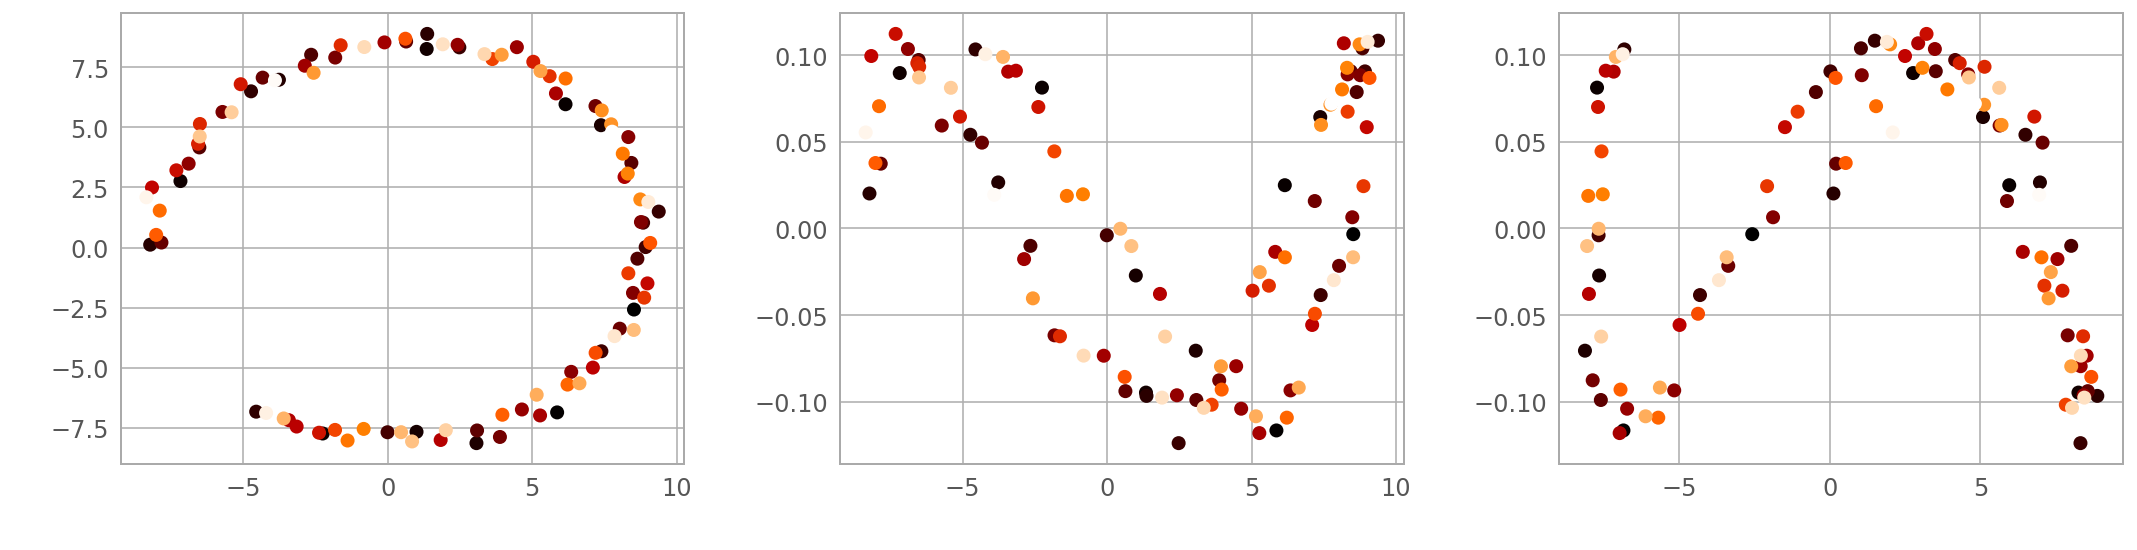

In [4]:
fig, axs = plt.subplots(1, 3, figsize=(15, 4))

axs[0].scatter(orb_obs.x, orb_obs.y, c=orb_clr)
axs[1].scatter(orb_obs.x, orb_obs.z, c=orb_clr)
axs[2].scatter(orb_obs.y, orb_obs.z, c=orb_clr)
plt.tight_layout()
plt.show();

### Preprocessing

In [5]:
orb_repdata, orb_trmat, orb_visit_orders, orb_start_point = prep.preprocess(
    orb_obs,
    start_point=np.array((-6, -6, 0.0)),
    iterations=int(3e3),
    learning_rate=1.5,
    sigma=15,
    plot=False,
    random_seeds=np.arange(0, 10, 1),
    _tqdm=True,
)

orb_best_order = prep.draw_most_probable_ordering(orb_trmat)
orb_arr = orb_repdata[orb_best_order].xyz.T.value

  0%|          | 0/10 [00:00<?, ?it/s]

/Users/nathanielstarkman/miniconda3/envs/dev/lib/python3.8/site-packages/minisom.py:365: UserWarning: PCA initialization inappropriate:One of the dimensions of the map is 1.
  warn(msg)



100%|██████████| 10/10 [00:01<00:00,  5.66it/s]


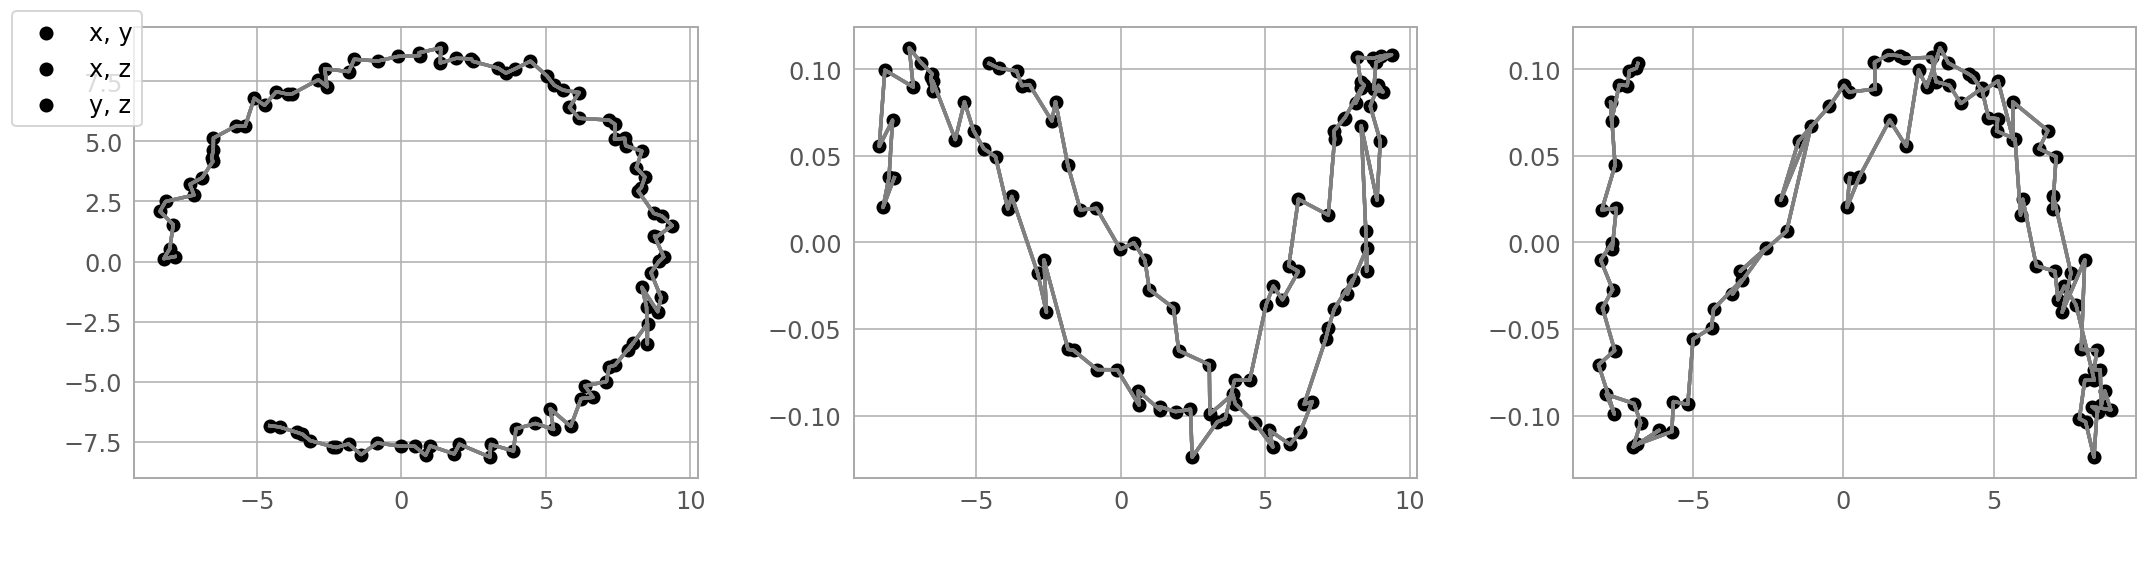

In [6]:
fig, axs = plt.subplots(1, 3, figsize=(15, 4))

# x, y
axs[0].scatter(orb_repdata.x, orb_repdata.y, label="x, y",
               c="k", vmax=len(orb_repdata), cmap="plasma")
for order in orb_visit_orders:
    axs[0].plot(orb_repdata[order].x, orb_repdata[order].y, c="gray", alpha=0.5)

# x, z
axs[1].scatter(orb_repdata.x, orb_repdata.z, label="x, z",
               c="k", vmax=len(orb_repdata), cmap="plasma")
for order in orb_visit_orders:
    axs[1].plot(orb_repdata[order].x, orb_repdata[order].z, c="gray", alpha=0.5)
    
# y, z
axs[2].scatter(orb_repdata.y, orb_repdata.z, label="y, z",
               c="k", vmax=len(orb_repdata), cmap="plasma")
for order in orb_visit_orders:
    axs[2].plot(orb_repdata[order].y, orb_repdata[order].z, c="gray", alpha=0.5)

fig.legend(loc="upper left")
fig.tight_layout()
plt.show();

### Kalman Filter

In [7]:
orb_kf = KalmanFilter(
    dim_x=6,  # x, dx, y, dy, z, dz
    dim_z=3,  # (x, y, z)
)

In [8]:
dt = 0.5   # "time" step

#### State transition function

In [9]:
F_comp = np.array([[1, dt], [0, 1]])

orb_kf.F = block_diag(F_comp, F_comp, F_comp)
orb_kf.F

array([[1. , 0.5, 0. , 0. , 0. , 0. ],
       [0. , 1. , 0. , 0. , 0. , 0. ],
       [0. , 0. , 1. , 0.5, 0. , 0. ],
       [0. , 0. , 0. , 1. , 0. , 0. ],
       [0. , 0. , 0. , 0. , 1. , 0.5],
       [0. , 0. , 0. , 0. , 0. , 1. ]])

#### Process noise matrix

In [10]:
orb_kf.Q = Q_discrete_white_noise(dim=2, dt=dt, var=0.01, block_size=3)

orb_kf.Q

array([[0.00015625, 0.000625  , 0.        , 0.        , 0.        ,
        0.        ],
       [0.000625  , 0.0025    , 0.        , 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.00015625, 0.000625  , 0.        ,
        0.        ],
       [0.        , 0.        , 0.000625  , 0.0025    , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.00015625,
        0.000625  ],
       [0.        , 0.        , 0.        , 0.        , 0.000625  ,
        0.0025    ]])

#### Measurement function

In [11]:
# measurement components
# only measure the position 
h = np.array([[1, 0],
              [0, 0]])

# full matrix is for all components
# and reduce down to `dim_z` of Kalman Filter, skipping velocity rows
orb_kf.H = block_diag(h, h, h)[::2]

orb_kf.H

array([[1, 0, 0, 0, 0, 0],
       [0, 0, 1, 0, 0, 0],
       [0, 0, 0, 0, 1, 0]])

#### Measurement noise matrix

In [12]:
orb_kf.R = np.diag([
    0.05,  # error in x
    0.05,  # error in y
    0.003  # error in z
])

#### Initial conditions

Set the initial conditions to the first data point.

In [13]:
x = orb_arr[0]  # fist point
v = [0, 0, 0]

orb_kf.x = np.array([x, v]).T.flatten()  # intersperse velocity data
orb_kf.x

array([-4.55522669,  0.        , -6.82800967,  0.        ,  0.10330797,
        0.        ])

#### State Covariance

In [14]:
orb_kf.P = np.eye(6) * 100.

#### Run

In [15]:
orb_kfsave = Saver(orb_kf)

orb_Ms, orb_Ps, _, _ = orb_kf.batch_filter(orb_arr, saver=orb_kfsave)
orb_kfsave.to_array()
orb_sMs, orb_sPs, orb_sKs, orb_sPps  = orb_kf.rts_smoother(orb_kfsave.x, orb_kfsave.P, )

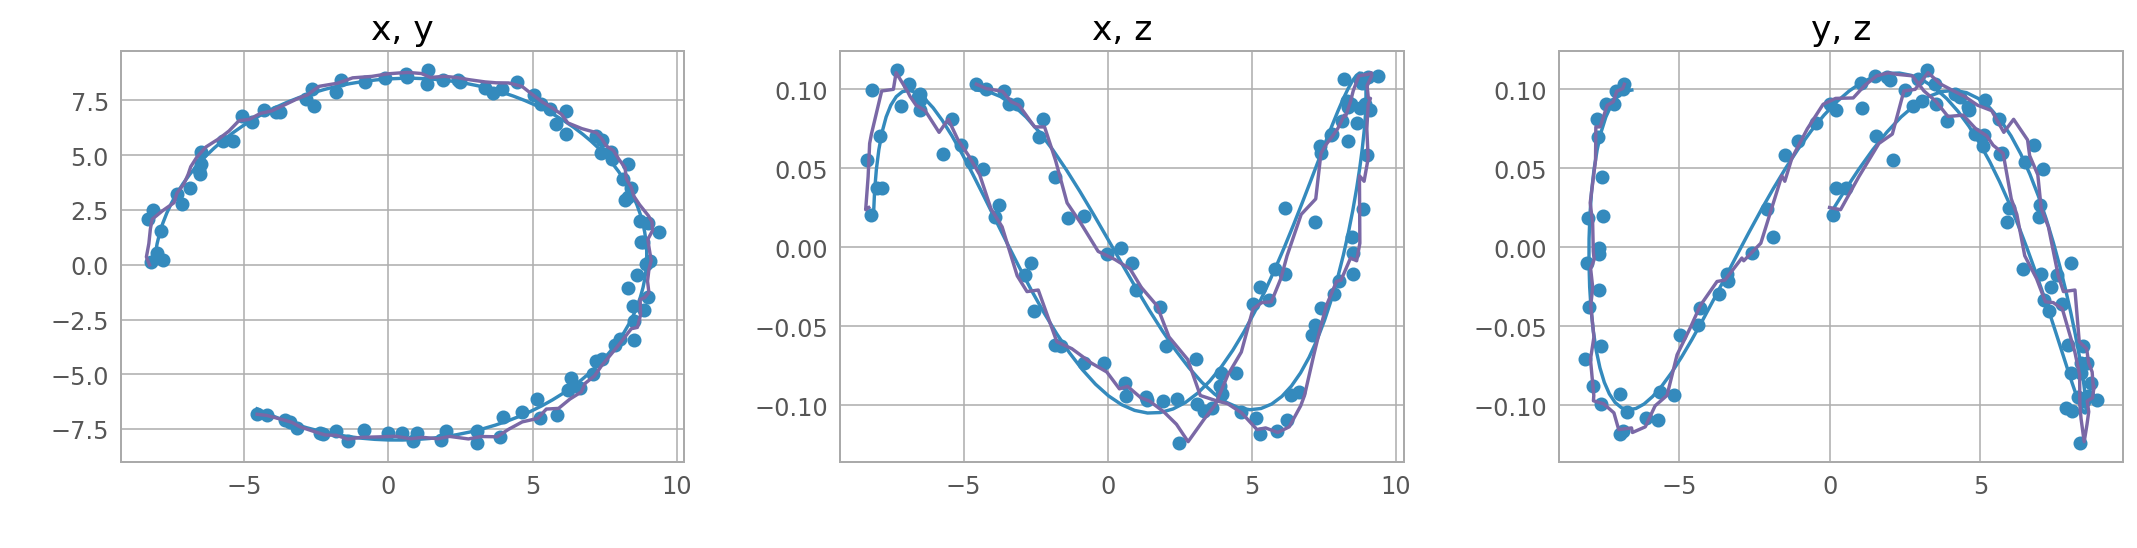

In [62]:
fig, axs = plt.subplots(1, 3, figsize=(15, 4))

axs[0].plot(orb_ord.x.value, orb_ord.y.value)
axs[0].scatter(orb_repdata.x, orb_repdata.y)
axs[0].plot(orb_Ms[:, 0], orb_Ms[:, 2])
axs[0].set_title("x, y")

axs[1].plot(orb_ord.x.value, orb_ord.z.value)
axs[1].scatter(orb_repdata.x, orb_repdata.z)
axs[1].plot(orb_Ms[:, 0], orb_Ms[:, 4])
axs[1].set_title("x, z")

axs[2].plot(orb_ord.y.value, orb_ord.z.value)
axs[2].scatter(orb_repdata.y, orb_repdata.z)
axs[2].plot(orb_Ms[:, 2], orb_Ms[:, 4])
axs[2].set_title("y, z")

plt.tight_layout()
plt.show();

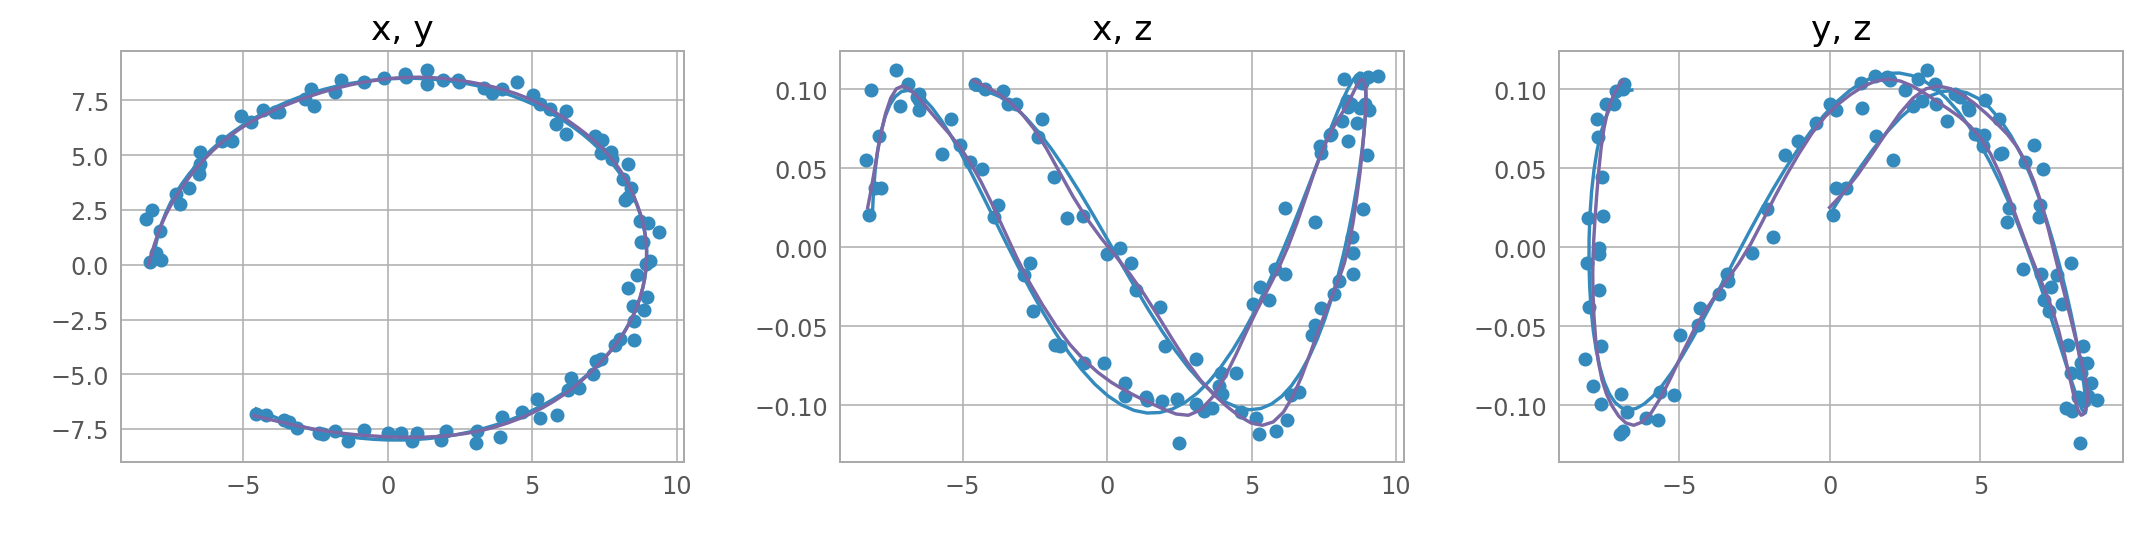

In [16]:
fig, axs = plt.subplots(1, 3, figsize=(15, 4))

axs[0].plot(orb_ord.x.value, orb_ord.y.value)
axs[0].scatter(orb_repdata.x, orb_repdata.y)
axs[0].plot(orb_sMs[:, 0], orb_sMs[:, 2])
axs[0].set_title("x, y")

axs[1].plot(orb_ord.x.value, orb_ord.z.value)
axs[1].scatter(orb_repdata.x, orb_repdata.z)
axs[1].plot(orb_sMs[:, 0], orb_sMs[:, 4])
axs[1].set_title("x, z")

axs[2].plot(orb_ord.y.value, orb_ord.z.value)
axs[2].scatter(orb_repdata.y, orb_repdata.z)
axs[2].plot(orb_sMs[:, 2], orb_sMs[:, 4])
axs[2].set_title("y, z")

plt.tight_layout()
plt.show();

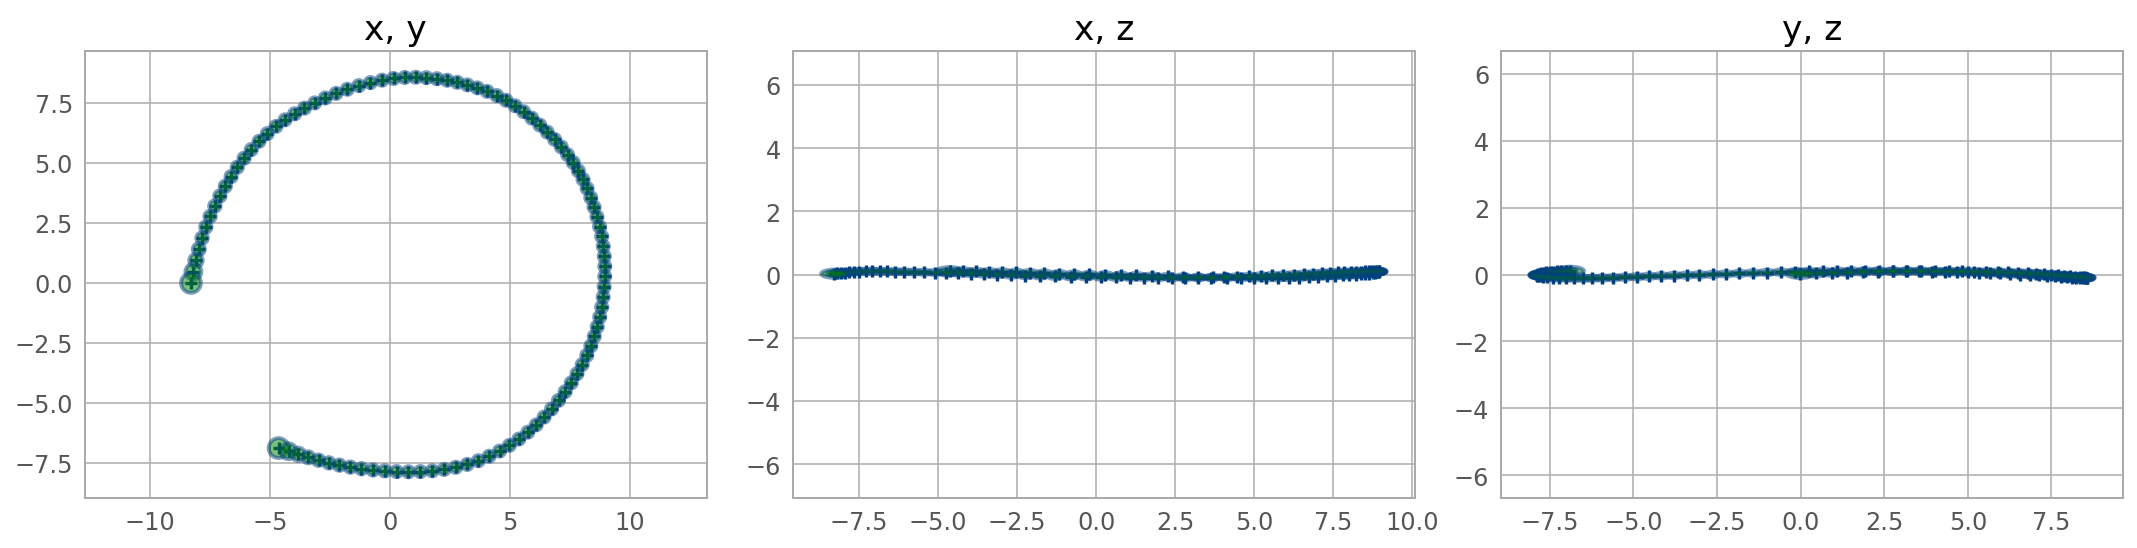

In [18]:
fig, axs = plt.subplots(1, 3, figsize=(15, 4))

for x, P in zip(orb_sMs, orb_sPs):
    # covariance of x and y
    cov = np.array([[P[0, 0], P[2, 0]], 
                    [P[0, 2], P[2, 2]]])
    mean = (x[0], x[2])

    plt.sca(axs[0])
    plot_covariance(mean, cov=cov, fc='g', std=3, alpha=0.5, title="x, y")
    
    # covariance of x and z
    cov = np.array([[P[0, 0], P[4, 0]], 
                    [P[0, 4], P[4, 4]]])
    mean = (x[0], x[4])

    plt.sca(axs[1])
    plot_covariance(mean, cov=cov, fc='g', std=3, alpha=0.5, ylim=(-1, 1), title="x, z")

    # covariance of y and z
    cov = np.array([[P[2, 2], P[4, 2]], 
                    [P[2, 4], P[4, 4]]])
    mean = (x[2], x[4])

    plt.sca(axs[2])
    plot_covariance(mean, cov=cov, fc='g', std=3, alpha=0.5, ylim=(-1, 1), title="y, z")

plt.tight_layout()
plt.show();

<br><br><br>

<br><br>

- - - 


## Nbody Data

In [19]:
nbd_obs = examples.get_nbody()

nbd_clr = np.linspace(0, 256, len(nbd_obs))

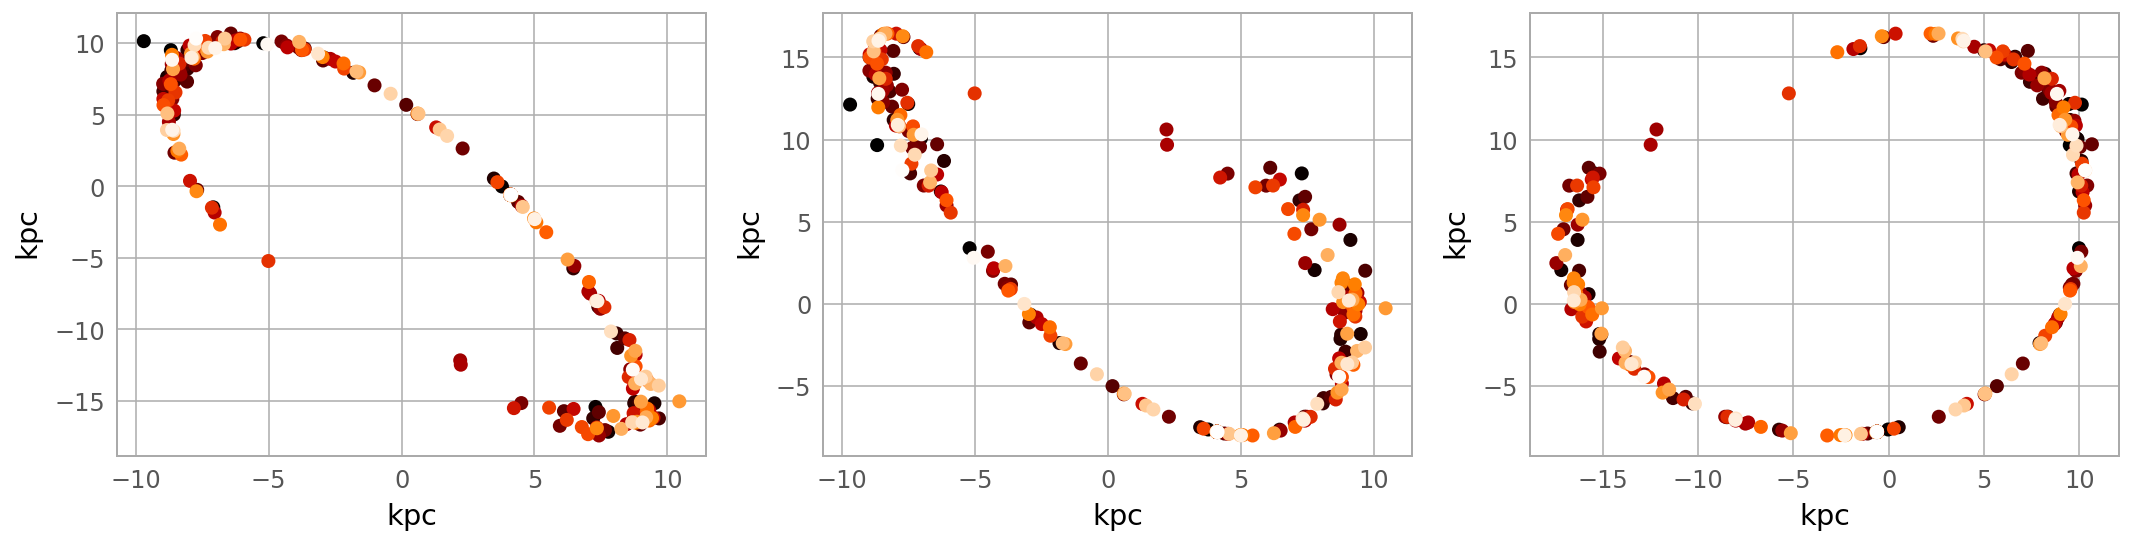

In [20]:
fig, axs = plt.subplots(1, 3, figsize=(15, 4))

axs[0].scatter(nbd_obs.x, nbd_obs.y, c=nbd_clr)
axs[1].scatter(nbd_obs.x, nbd_obs.z, c=nbd_clr)
axs[2].scatter(nbd_obs.y, nbd_obs.z, c=nbd_clr)
plt.tight_layout()
plt.show();

### Preprocessing

In [21]:
nbd_repdata, nbd_trmat, nbd_visit_orders, nbd_start_point = prep.preprocess(
    nbd_obs,
    start_point=np.array((-5, -5, 12.0)),
    iterations=int(3e3),
    learning_rate=2.,
    sigma=20,
    plot=False,
    random_seeds=np.arange(10, 20, 1),
    _tqdm=True,
)

nbd_best_order = prep.draw_most_probable_ordering(nbd_trmat)
nbd_arr = nbd_repdata[nbd_best_order].data.xyz.T.value

  0%|          | 0/10 [00:00<?, ?it/s]

/Users/nathanielstarkman/miniconda3/envs/dev/lib/python3.8/site-packages/minisom.py:365: UserWarning: PCA initialization inappropriate:One of the dimensions of the map is 1.
  warn(msg)



100%|██████████| 10/10 [00:02<00:00,  3.45it/s]


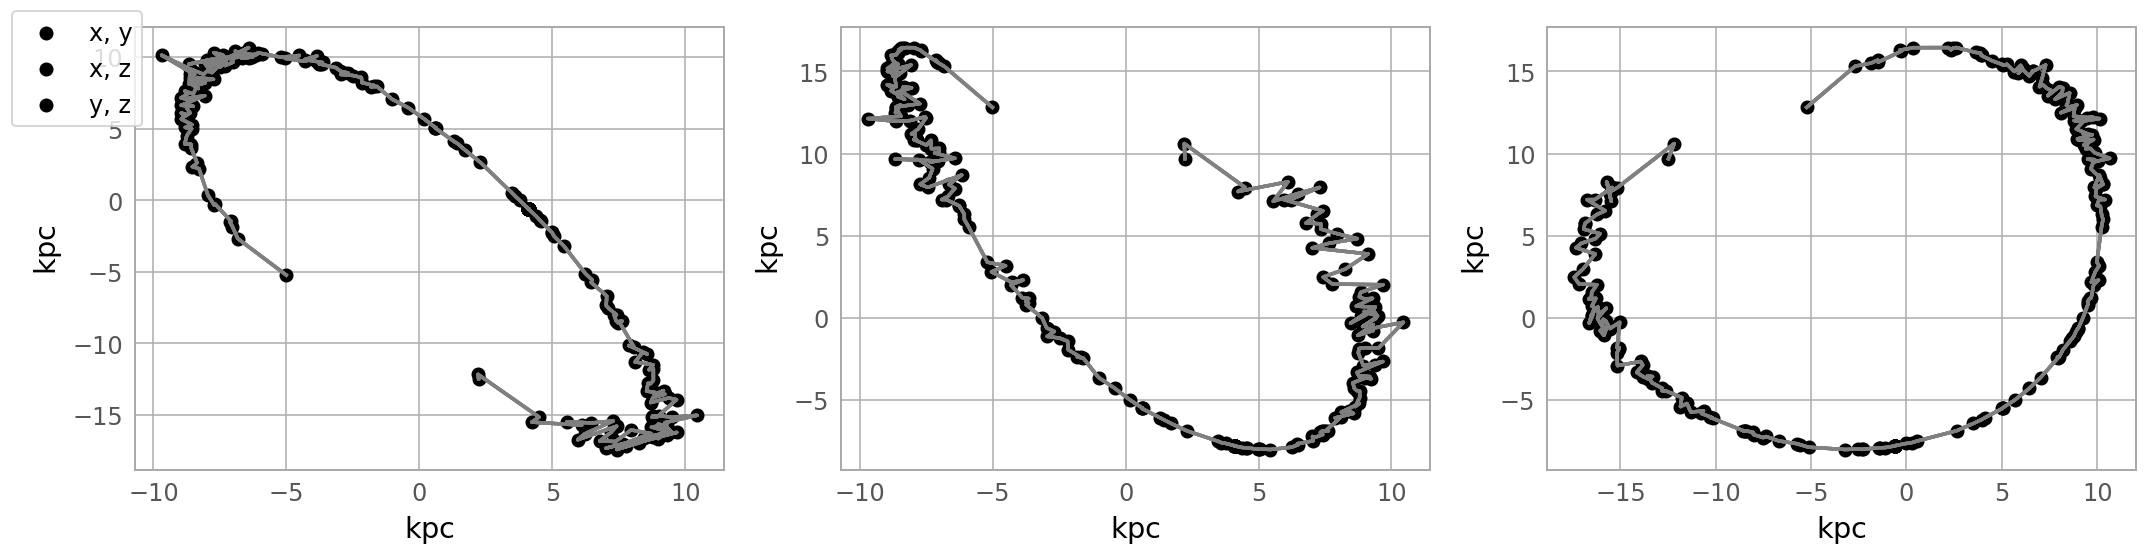

In [22]:
fig, axs = plt.subplots(1, 3, figsize=(15, 4))

# x, y
axs[0].scatter(nbd_repdata.x, nbd_repdata.y, label="x, y",
               c="k", vmax=len(nbd_repdata), cmap="plasma")
for order in nbd_visit_orders:
    axs[0].plot(nbd_repdata[order].x, nbd_repdata[order].y, c="gray", alpha=0.5)

# x, z
axs[1].scatter(nbd_repdata.x, nbd_repdata.z, label="x, z",
               c="k", vmax=len(nbd_repdata), cmap="plasma")
for order in nbd_visit_orders:
    axs[1].plot(nbd_repdata[order].x, nbd_repdata[order].z, c="gray", alpha=0.5)
    
# y, z
axs[2].scatter(nbd_repdata.y, nbd_repdata.z, label="y, z",
               c="k", vmax=len(nbd_repdata), cmap="plasma")
for order in nbd_visit_orders:
    axs[2].plot(nbd_repdata[order].y, nbd_repdata[order].z, c="gray", alpha=0.5)

fig.legend(loc="upper left")
fig.tight_layout()
plt.show();

### Kalman Filter

In [23]:
nbd_kf = KalmanFilter(
    dim_x=6,  # x, dx, y, dy, z, dz
    dim_z=3,  # (x, y, z)
)

In [24]:
dt = 0.5   # "time" step

#### State transition function

In [25]:
F_comp = np.array([[1, dt], [0, 1]])

nbd_kf.F = block_diag(F_comp, F_comp, F_comp)
nbd_kf.F

array([[1. , 0.5, 0. , 0. , 0. , 0. ],
       [0. , 1. , 0. , 0. , 0. , 0. ],
       [0. , 0. , 1. , 0.5, 0. , 0. ],
       [0. , 0. , 0. , 1. , 0. , 0. ],
       [0. , 0. , 0. , 0. , 1. , 0.5],
       [0. , 0. , 0. , 0. , 0. , 1. ]])

#### Process noise matrix

In [26]:
nbd_kf.Q = Q_discrete_white_noise(dim=2, dt=dt, var=0.01, block_size=3)

nbd_kf.Q

array([[0.00015625, 0.000625  , 0.        , 0.        , 0.        ,
        0.        ],
       [0.000625  , 0.0025    , 0.        , 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.00015625, 0.000625  , 0.        ,
        0.        ],
       [0.        , 0.        , 0.000625  , 0.0025    , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.00015625,
        0.000625  ],
       [0.        , 0.        , 0.        , 0.        , 0.000625  ,
        0.0025    ]])

#### Measurement function

In [27]:
# measurement components
# only measure the position 
h = np.array([[1, 0],
              [0, 0]])

# full matrix is for all components
# and reduce down to `dim_z` of Kalman Filter, skipping velocity rows
nbd_kf.H = block_diag(h, h, h)[::2]

nbd_kf.H

array([[1, 0, 0, 0, 0, 0],
       [0, 0, 1, 0, 0, 0],
       [0, 0, 0, 0, 1, 0]])

#### Measurement noise matrix

In [36]:
nbd_kf.R = np.diag([
    0.05,  # error in x
    0.05,  # error in y
    0.003  # error in z
])

#### Initial conditions

Set the initial conditions to the first data point.

In [37]:
x = nbd_arr[0]  # fist point
v = [0, 0, 0]

nbd_kf.x = np.array([x, v]).T.flatten()  # intersperse velocity data
nbd_kf.x

array([-5.0065478 ,  0.        , -5.23145347,  0.        , 12.81172138,
        0.        ])

#### State Covariance

In [38]:
nbd_kf.P = np.eye(6) * 100.

#### Run

In [39]:
nbd_kfsave = Saver(nbd_kf)

nbd_Ms, nbd_Ps, _, _ = nbd_kf.batch_filter(nbd_arr, saver=nbd_kfsave)
nbd_kfsave.to_array()
nbd_sMs, nbd_sPs, nbd_sKs, nbd_sPps  = nbd_kf.rts_smoother(nbd_kfsave.x, nbd_kfsave.P, )

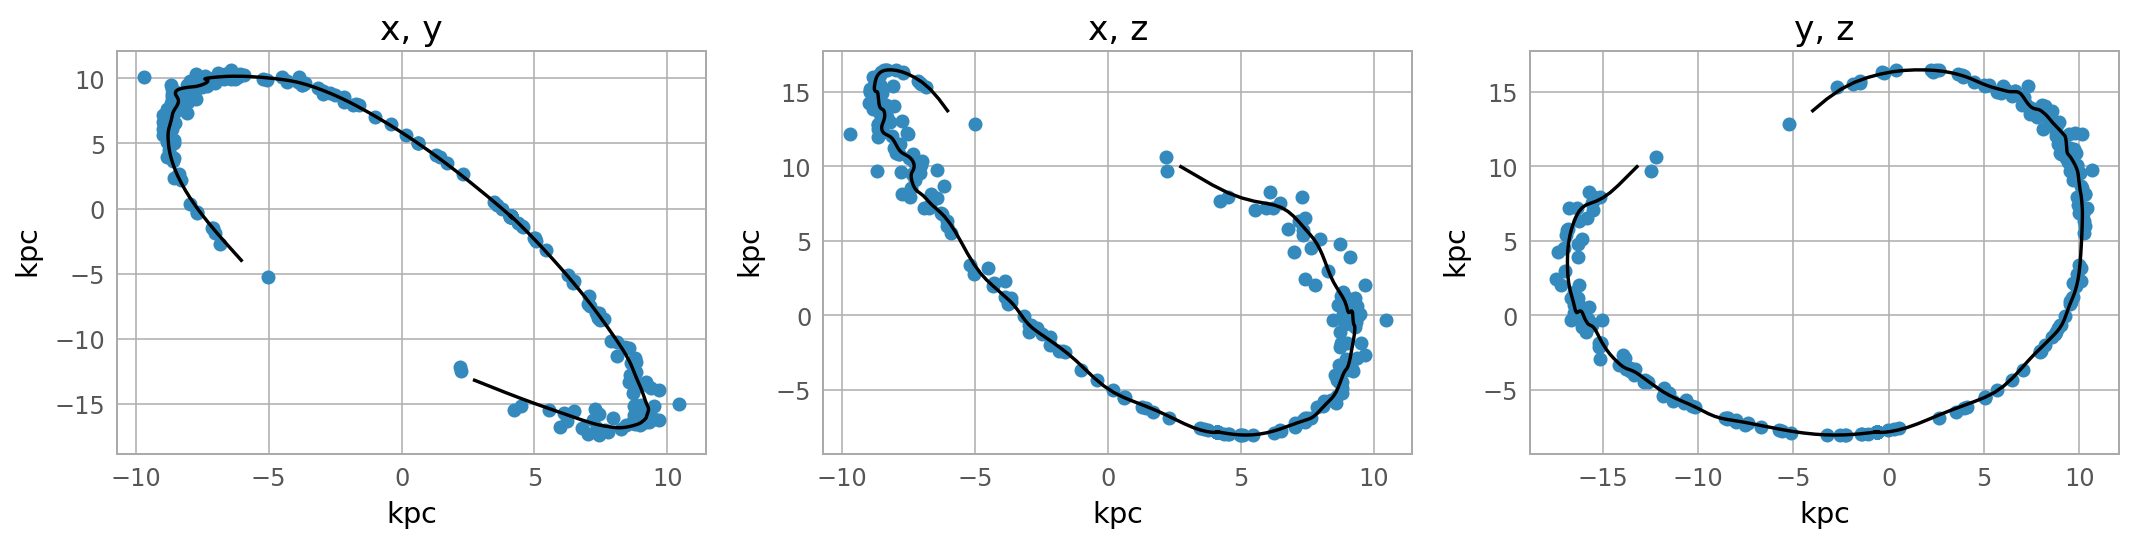

In [40]:
fig, axs = plt.subplots(1, 3, figsize=(15, 4))

axs[0].scatter(nbd_repdata.x, nbd_repdata.y)
axs[0].plot(nbd_sMs[:, 0], nbd_sMs[:, 2], c="k")
axs[0].set_title("x, y")

axs[1].scatter(nbd_repdata.x, nbd_repdata.z)
axs[1].plot(nbd_sMs[:, 0], nbd_sMs[:, 4], c="k")
axs[1].set_title("x, z")

axs[2].scatter(nbd_repdata.y, nbd_repdata.z)
axs[2].plot(nbd_sMs[:, 2], nbd_sMs[:, 4], c="k")
axs[2].set_title("y, z")

plt.tight_layout()
plt.show();

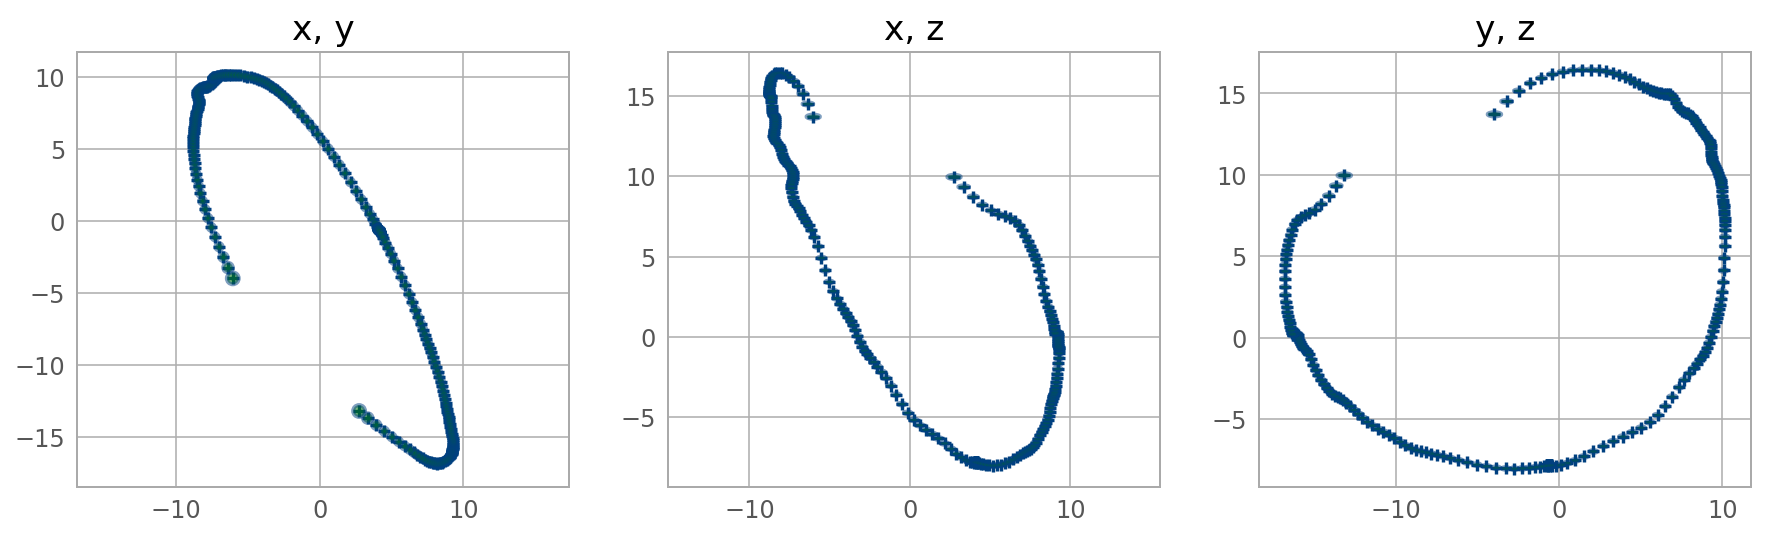

In [41]:
fig, axs = plt.subplots(1, 3, figsize=(15, 4))

for x, P in zip(nbd_sMs, nbd_sPs):
    # covariance of x and y
    cov = np.array([[P[0, 0], P[2, 0]], 
                    [P[0, 2], P[2, 2]]])
    mean = (x[0], x[2])

    plt.sca(axs[0])
    plot_covariance(mean, cov=cov, fc='g', std=3, alpha=0.5, title="x, y")
    
    # covariance of x and z
    cov = np.array([[P[0, 0], P[4, 0]], 
                    [P[0, 4], P[4, 4]]])
    mean = (x[0], x[4])

    plt.sca(axs[1])
    plot_covariance(mean, cov=cov, fc='g', std=3, alpha=0.5, title="x, z")
    
    # covariance of y and z
    cov = np.array([[P[2, 2], P[4, 2]], 
                    [P[2, 4], P[4, 4]]])
    mean = (x[2], x[4])

    plt.sca(axs[2])
    plot_covariance(mean, cov=cov, fc='g', std=3, alpha=0.5, title="y, z")

<br><br>

- - - 


## Obs Data

In [42]:
pal5_obs = examples.get_stream_data().cartesian

pal5_clr = np.linspace(0, 256, len(pal5_obs))

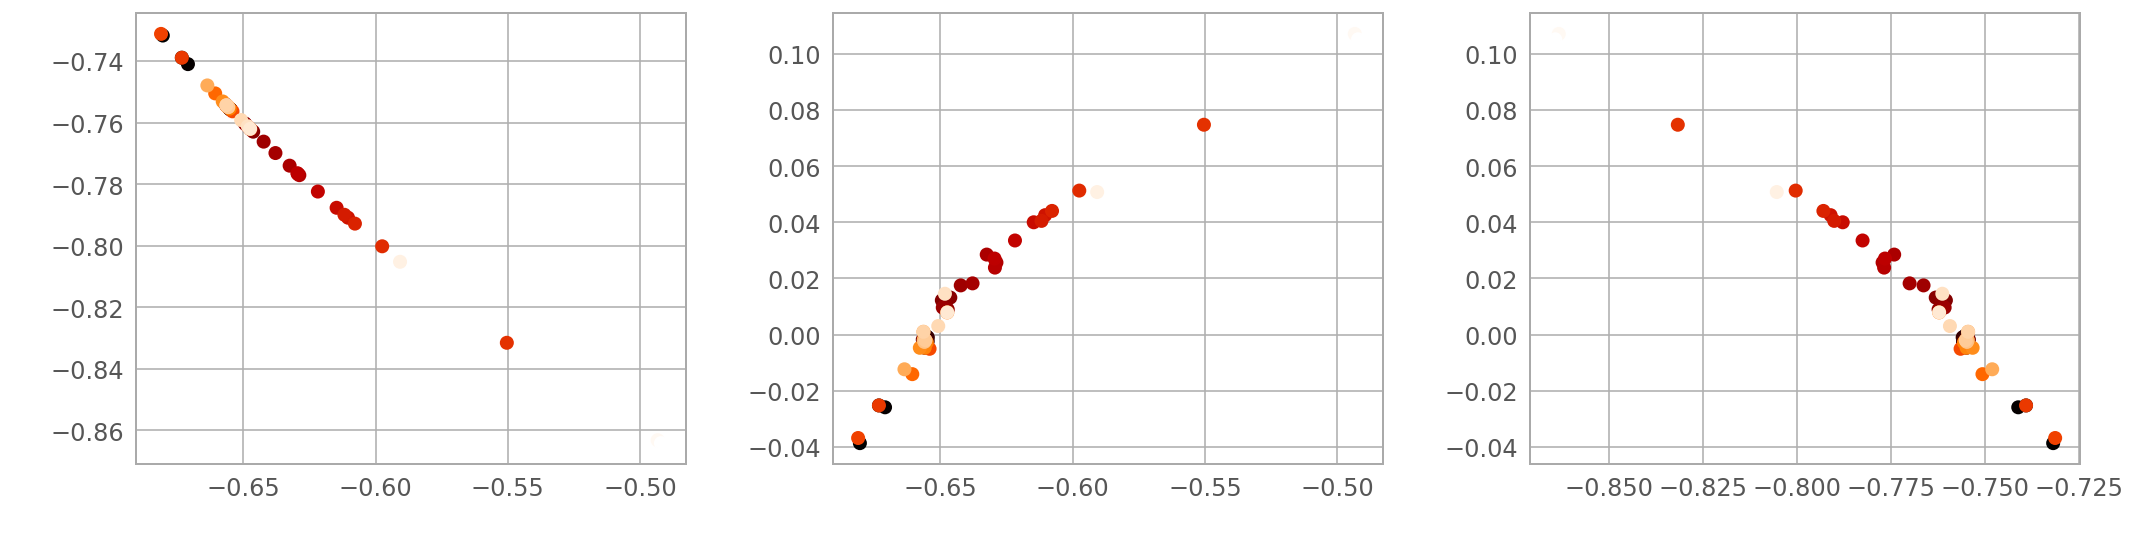

In [43]:
fig, axs = plt.subplots(1, 3, figsize=(15, 4))

axs[0].scatter(pal5_obs.x, pal5_obs.y, c=pal5_clr)
axs[1].scatter(pal5_obs.x, pal5_obs.z, c=pal5_clr)
axs[2].scatter(pal5_obs.y, pal5_obs.z, c=pal5_clr)
plt.tight_layout()
plt.show();

### Preprocessing

In [44]:
pal5_repdata, pal5_trmat, pal5_visit_orders, pal5_start_point = prep.preprocess(
    pal5_obs,
    start_point=np.array((-0.7, -0.72, -0.04)),
    iterations=int(3e3),
    learning_rate=2.,
    sigma=20,
    plot=False,
    random_seeds=np.arange(10, 20, 1),
    _tqdm=True,
)

pal5_best_order = prep.draw_most_probable_ordering(pal5_trmat)
pal5_arr = pal5_repdata[pal5_best_order].xyz.T.value

  0%|          | 0/10 [00:00<?, ?it/s]

/Users/nathanielstarkman/miniconda3/envs/dev/lib/python3.8/site-packages/minisom.py:365: UserWarning: PCA initialization inappropriate:One of the dimensions of the map is 1.
  warn(msg)



100%|██████████| 10/10 [00:01<00:00,  6.30it/s]


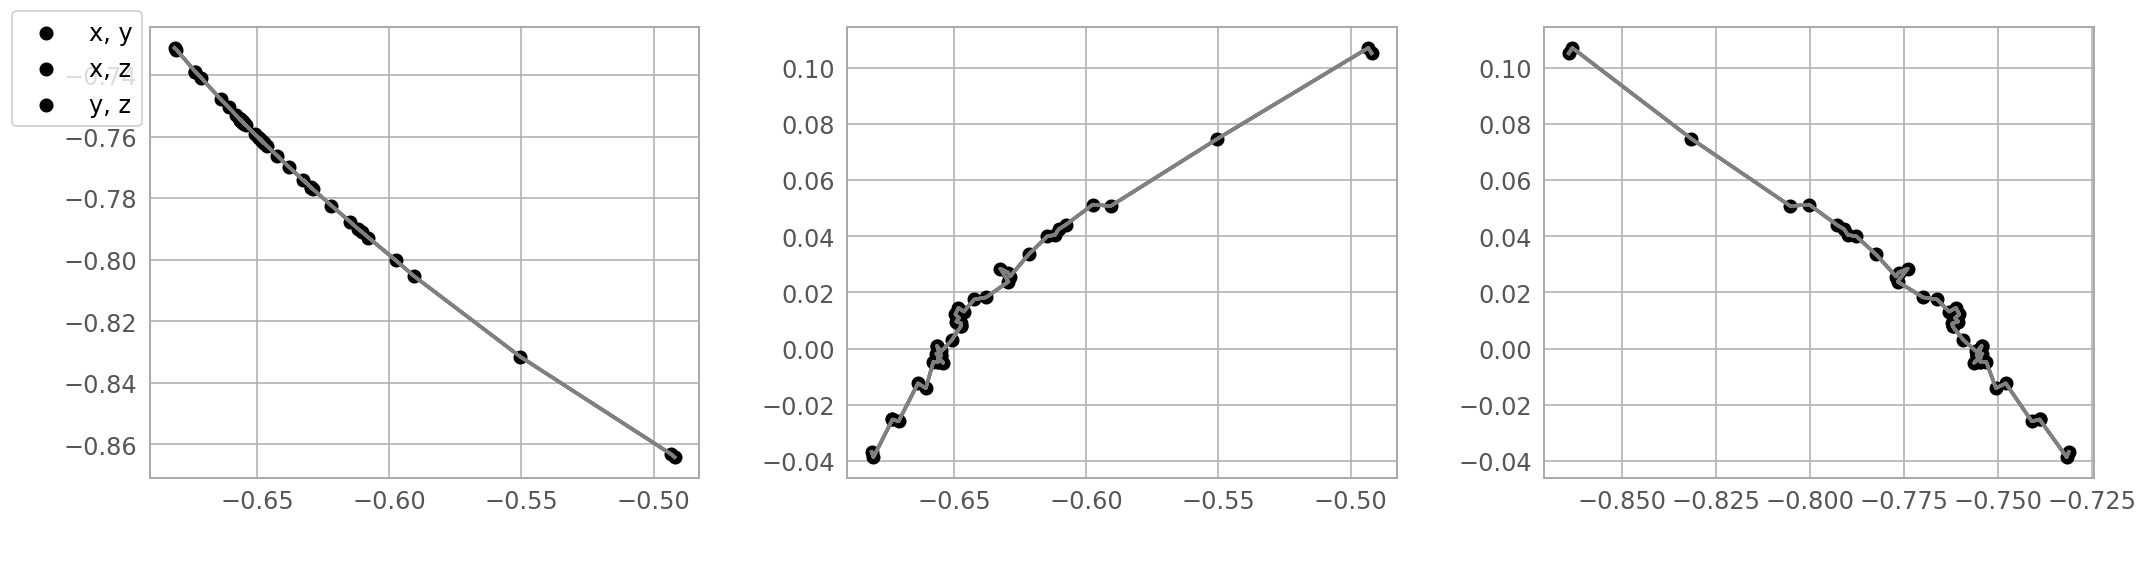

In [45]:
fig, axs = plt.subplots(1, 3, figsize=(15, 4))

# x, y
axs[0].scatter(pal5_repdata.x, pal5_repdata.y, label="x, y",
               c="k", vmax=len(pal5_repdata), cmap="plasma")
for order in pal5_visit_orders:
    axs[0].plot(pal5_repdata[order].x, pal5_repdata[order].y, c="gray", alpha=0.5)

# x, z
axs[1].scatter(pal5_repdata.x, pal5_repdata.z, label="x, z",
               c="k", vmax=len(pal5_repdata), cmap="plasma")
for order in pal5_visit_orders:
    axs[1].plot(pal5_repdata[order].x, pal5_repdata[order].z, c="gray", alpha=0.5)
    
# y, z
axs[2].scatter(pal5_repdata.y, pal5_repdata.z, label="y, z",
               c="k", vmax=len(pal5_repdata), cmap="plasma")
for order in pal5_visit_orders:
    axs[2].plot(pal5_repdata[order].y, pal5_repdata[order].z, c="gray", alpha=0.5)

fig.legend(loc="upper left")
fig.tight_layout()
plt.show();

### Kalman Filter

In [46]:
pal5_kf = KalmanFilter(
    dim_x=6,  # x, dx, y, dy, z, dz
    dim_z=3,  # (x, y, z)
)

In [47]:
dt = 0.5   # "time" step

#### State transition function

In [48]:
F_comp = np.array([[1, dt], [0, 1]])

pal5_kf.F = block_diag(F_comp, F_comp, F_comp)
pal5_kf.F

array([[1. , 0.5, 0. , 0. , 0. , 0. ],
       [0. , 1. , 0. , 0. , 0. , 0. ],
       [0. , 0. , 1. , 0.5, 0. , 0. ],
       [0. , 0. , 0. , 1. , 0. , 0. ],
       [0. , 0. , 0. , 0. , 1. , 0.5],
       [0. , 0. , 0. , 0. , 0. , 1. ]])

#### Process noise matrix

In [49]:
pal5_kf.Q = Q_discrete_white_noise(dim=2, dt=dt, var=0.01, block_size=3) / 10

pal5_kf.Q

array([[1.5625e-05, 6.2500e-05, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00],
       [6.2500e-05, 2.5000e-04, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00],
       [0.0000e+00, 0.0000e+00, 1.5625e-05, 6.2500e-05, 0.0000e+00,
        0.0000e+00],
       [0.0000e+00, 0.0000e+00, 6.2500e-05, 2.5000e-04, 0.0000e+00,
        0.0000e+00],
       [0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 1.5625e-05,
        6.2500e-05],
       [0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 6.2500e-05,
        2.5000e-04]])

#### Measurement function

In [50]:
# measurement components
# only measure the position 
h = np.array([[1, 0],
              [0, 0]])

# full matrix is for all components
# and reduce down to `dim_z` of Kalman Filter, skipping velocity rows
pal5_kf.H = block_diag(h, h, h)[::2]

pal5_kf.H

array([[1, 0, 0, 0, 0, 0],
       [0, 0, 1, 0, 0, 0],
       [0, 0, 0, 0, 1, 0]])

#### Measurement noise matrix

In [51]:
pal5_kf.R = np.diag([
    1e-5,  # error in x
    1e-5,  # error in y
    1e-5  # error in z
])

#### Initial conditions

Set the initial conditions to the first data point.

In [52]:
x = pal5_arr[0]  # fist point
v = [0, 0, 0]

pal5_kf.x = np.array([x, v]).T.flatten()  # intersperse velocity data
pal5_kf.x

array([-0.68115543,  0.        , -0.73121188,  0.        , -0.03683024,
        0.        ])

#### State Covariance

In [53]:
pal5_kf.P = np.eye(6) * 100

#### Run

In [54]:
pal5_kfsave = Saver(pal5_kf)

pal5_Ms, pal5_Ps, _, _ = pal5_kf.batch_filter(pal5_arr, saver=pal5_kfsave)
pal5_kfsave.to_array()
pal5_sMs, pal5_sPs, pal5_sKs, pal5_sPps = pal5_kf.rts_smoother(pal5_kfsave.x, pal5_kfsave.P, )

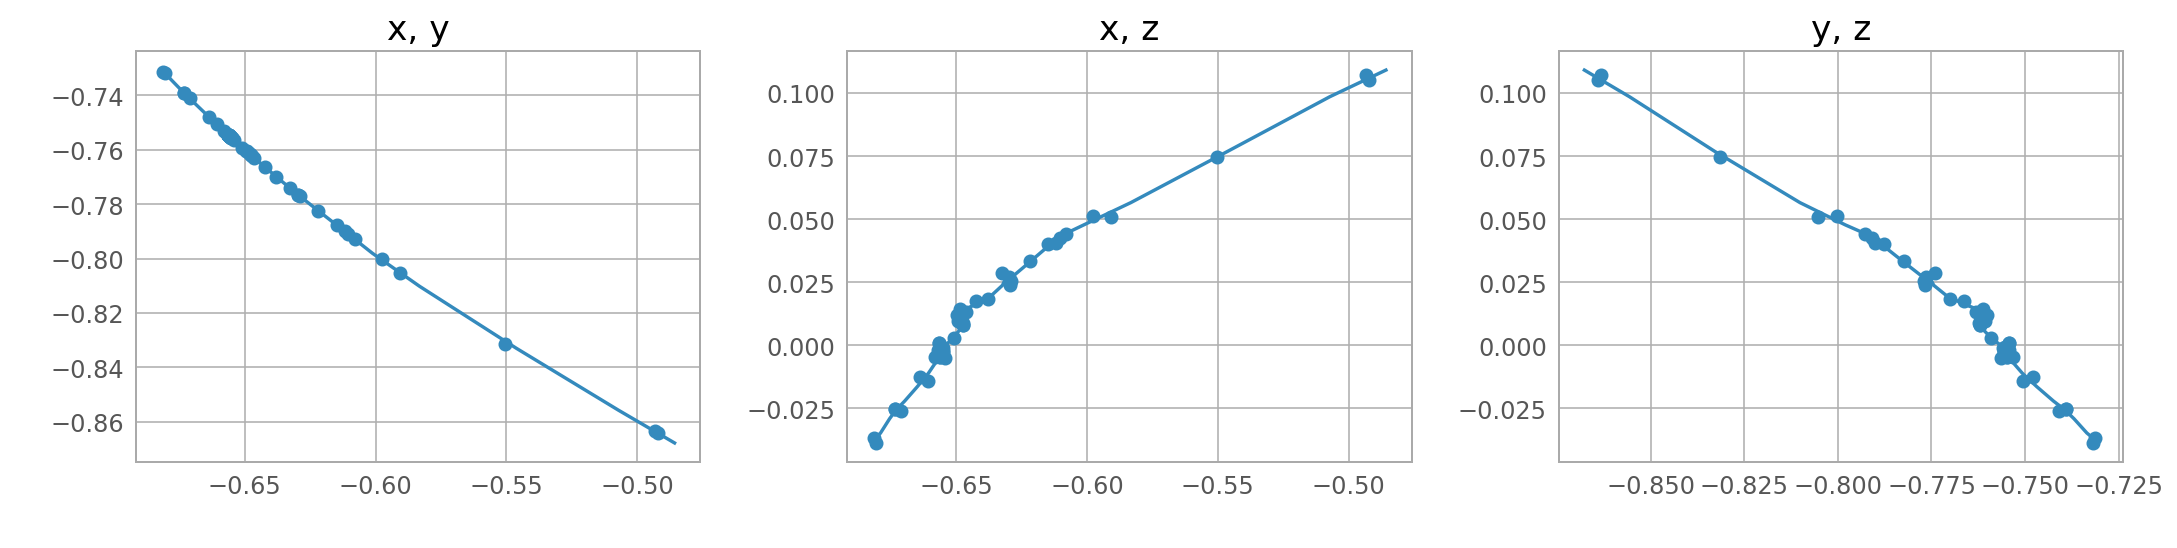

In [55]:
fig, axs = plt.subplots(1, 3, figsize=(15, 4))

axs[0].scatter(pal5_repdata.x, pal5_repdata.y)
axs[0].plot(pal5_sMs[:, 0], pal5_sMs[:, 2])
axs[0].set_title("x, y")

axs[1].scatter(pal5_repdata.x, pal5_repdata.z)
axs[1].plot(pal5_sMs[:, 0], pal5_sMs[:, 4])
axs[1].set_title("x, z")

axs[2].scatter(pal5_repdata.y, pal5_repdata.z)
axs[2].plot(pal5_sMs[:, 2], pal5_sMs[:, 4])
axs[2].set_title("y, z")

plt.tight_layout()
plt.show();

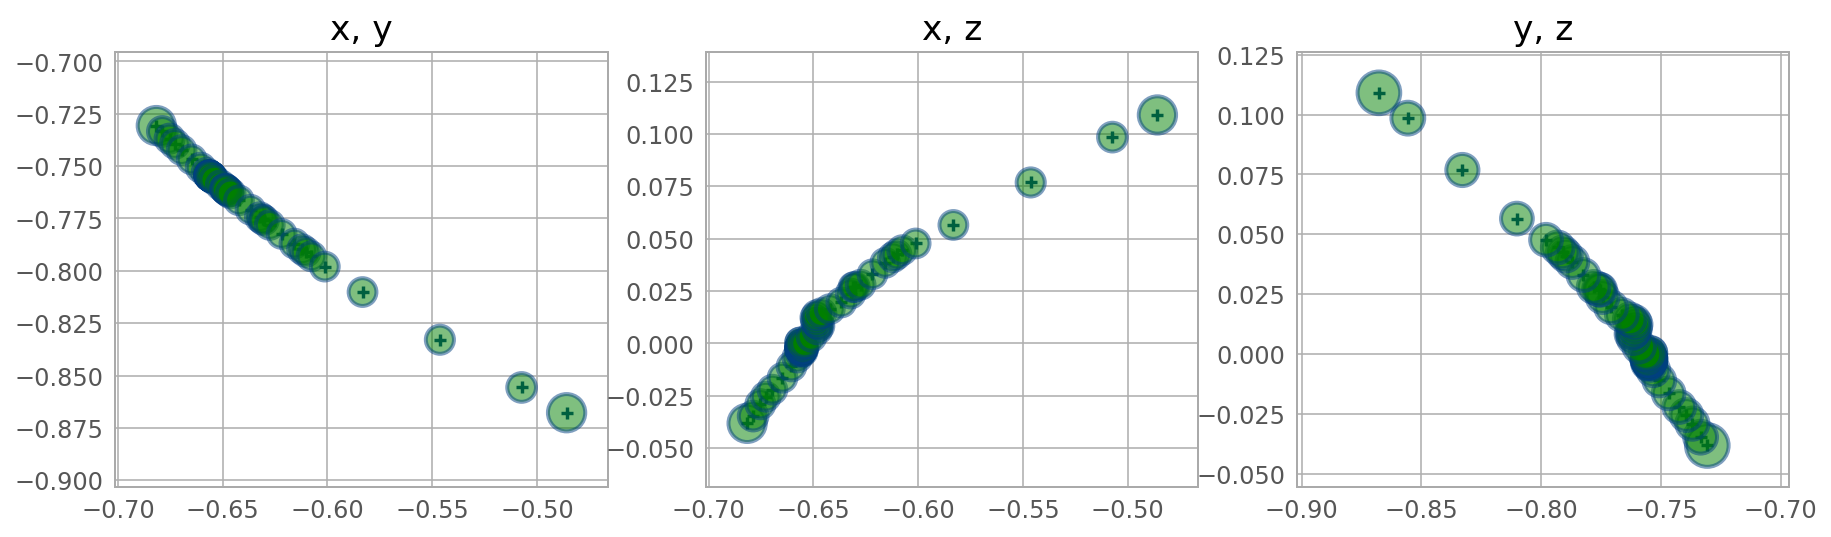

In [56]:
fig, axs = plt.subplots(1, 3, figsize=(15, 4))

for x, P in zip(pal5_sMs, pal5_sPs):
    # covariance of x and y
    cov = np.array([[P[0, 0], P[2, 0]], 
                    [P[0, 2], P[2, 2]]])
    mean = (x[0], x[2])

    plt.sca(axs[0])
    plot_covariance(mean, cov=cov, fc='g', std=3, alpha=0.5, title="x, y")
    
    # covariance of x and z
    cov = np.array([[P[0, 0], P[4, 0]], 
                    [P[0, 4], P[4, 4]]])
    mean = (x[0], x[4])

    plt.sca(axs[1])
    plot_covariance(mean, cov=cov, fc='g', std=3, alpha=0.5, title="x, z")
    
    # covariance of y and z
    cov = np.array([[P[2, 2], P[4, 2]], 
                    [P[2, 4], P[4, 4]]])
    mean = (x[2], x[4])

    plt.sca(axs[2])
    plot_covariance(mean, cov=cov, fc='g', std=3, alpha=0.5, title="y, z")


<br><br>

- - - 

<span style='font-size:40px;font-weight:650'>
    END
</span>